In [99]:
%pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [100]:
import math
import matplotlib.pyplot as plt

# Transformer layer

Here we will follow a token through a single transformer layer

## Tokenizer and model loading from previous parts

Nothing new here, just create a class for the tokenizer and loading of model weights.

In [101]:
from pathlib import Path
import json
import mmap
import regex
import numpy as np

class Tokenizer:

    def __init__(self, tokenizer_path: str):
        with open(tokenizer_path) as f:
            tokenizer_data = json.load(f)
        split = next(filter(lambda t: t["type"] == "Split", tokenizer_data["pre_tokenizer"]["pretokenizers"]))
        self.split_regex = regex.compile(split["pattern"]["Regex"])

        # space is encoded as Ġ, for simplicity, just use space here.
        self.vocab = {k.replace("Ġ", " ").encode("utf-8"): v for k, v in tokenizer_data["model"]["vocab"].items()}
        added_tokens = {t["content"]: t["id"] for t in tokenizer_data["added_tokens"]}

        self.vocab.update(added_tokens)

        # inverse vocabulary for detokenization
        self.vocab_inv = { v: k for k, v in self.vocab.items() }

    def tokenize(self, text: str) -> list[int]:
        str_tokens = self.split_regex.findall(text)

        # Add specific markers for beginning and end of text
        str_tokens = ["<|begin_of_text|>"] + str_tokens + ["<|end_of_text|>"]

        tokens = []

        for str_token in str_tokens:
            parts = [bytes([b]) for b in str_token.encode("utf-8")]

            while True:
                # Iterate over all pairs and find the pair we want to merge the most
                min_idx = None
                min_rank = None
                for i, pair in enumerate(zip(parts[:-1], parts[1:])):
                    rank = self.vocab.get(pair[0] + pair[1])
                    if rank is not None and (min_rank is None or rank < min_rank):
                        min_idx = i
                        min_rank = rank

                # If there were no pairs we could merge, we're done!
                if min_rank is None:
                    break
                assert min_idx is not None

                # Otherwise, merge that pair and leave the rest unchanged. Then repeat.
                parts = parts[:min_idx] + [parts[min_idx] + parts[min_idx + 1]] + parts[min_idx + 2 :]

            tokens.extend(self.vocab[part] for part in parts)

        return tokens

    def detokenize(self, tokens: list[int]) -> str:
        decoded = b""
        for t in tokens:
            decoded += self.vocab_inv[t]

        return decoded.decode("utf-8", errors="replace")


def load_raw_model(path: str):
    model_dir = Path(path)
    model = {}
    with open(model_dir / "metadata.json") as file:
        metadata = json.load(file)
    for tensor_name, tensor_metadata in metadata.items():
        if tensor_name == "__metadata__":
            continue
        file = open(model_dir / f"{tensor_name}.raw", mode="rb")
        mmaped = mmap.mmap(file.fileno(), 0, prot=mmap.PROT_READ)
        model[tensor_name] = np.frombuffer(mmaped, dtype=np.float32).reshape(tensor_metadata["shape"])
    return model

In [102]:
model_dir = Path("models/Llama-3.2-1B")

In [103]:
tokenizer = Tokenizer(model_dir / "tokenizer.json")
tensors = load_raw_model(model_dir / "tensors-fp32")
with open(model_dir / "config.json") as file:
    config = json.load(file)

In [104]:
config

{'architectures': ['LlamaForCausalLM'],
 'attention_bias': False,
 'attention_dropout': 0.0,
 'bos_token_id': 128000,
 'eos_token_id': 128001,
 'head_dim': 64,
 'hidden_act': 'silu',
 'hidden_size': 2048,
 'initializer_range': 0.02,
 'intermediate_size': 8192,
 'max_position_embeddings': 131072,
 'mlp_bias': False,
 'model_type': 'llama',
 'num_attention_heads': 32,
 'num_hidden_layers': 16,
 'num_key_value_heads': 8,
 'pretraining_tp': 1,
 'rms_norm_eps': 1e-05,
 'rope_scaling': {'factor': 32.0,
  'high_freq_factor': 4.0,
  'low_freq_factor': 1.0,
  'original_max_position_embeddings': 8192,
  'rope_type': 'llama3'},
 'rope_theta': 500000.0,
 'tie_word_embeddings': True,
 'torch_dtype': 'bfloat16',
 'transformers_version': '4.45.0.dev0',
 'use_cache': True,
 'vocab_size': 128256}

## Token embeddings

Get an embedding for a token to use afterwards

In [105]:
embed_tokens_weights = tensors["model.embed_tokens.weight"]

In [106]:
tokenized_text = tokenizer.tokenize("This is a hello world")
print(tokenized_text)
detokenized_text = tokenizer.detokenize(tokenized_text)
print(detokenized_text)

[27, 91, 7413, 3659, 4424, 91, 29, 2028, 374, 264, 24748, 1917, 27, 91, 408, 3659, 4424, 91, 29]
<|begin_of_text|>This is a hello world<|end_of_text|>


Get the embedding vector for a token

In [ ]:
# Use the first token: <|begin_of_text|>
token_index = 0
embedded_token = embed_tokens_weights[tokenized_text[token_index]]

(2048,)

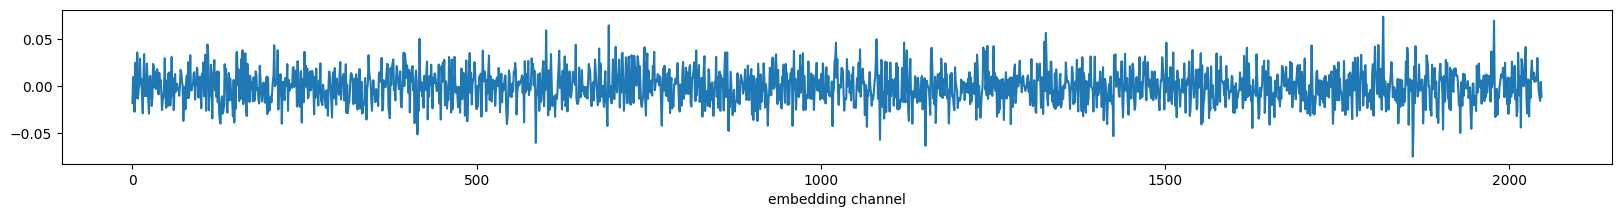

In [63]:
plt.figure(figsize = (20,2))
display(embedded_token.shape)
plt.xlabel("embedding channel")
plt.plot(embedded_token)

## Attention block

### First layer attention

We will navigate through a single attention block, one step at the time

In [64]:
layer_index = 0
max_seq_len = 50

First create an [RMS Normalization](https://arxiv.org/pdf/1910.07467) layer

RMSNorm rescales a vector using its root-mean-square value

In [65]:
class RMSNorm:

    def __init__(self, weights, eps):
        self.weights = weights
        self.eps = eps

    def __call__(self, x):
        x_squared = x ** 2
        rms = np.sqrt(x_squared.mean() + self.eps)
        rms_norm = (x / rms) * self.weights
        return rms_norm

Initialize it with the first transformer's layer weights

In [66]:
rmsnorm = RMSNorm(
    tensors[f"model.layers.{layer_index}.input_layernorm.weight"],
    config["rms_norm_eps"]
)

Then apply it on the embedded token

(2048,)

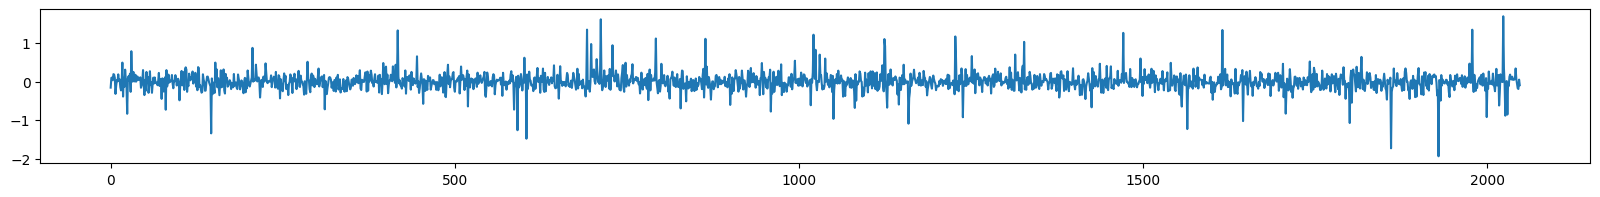

In [67]:
rmsnorm_embedded_token = rmsnorm(embedded_token)
plt.figure(figsize = (20,2))
display(rmsnorm_embedded_token.shape)
plt.plot(rmsnorm_embedded_token)

Now we arrive at the attention stage

Here is the attention configuration

In [126]:
num_key_value_heads = config["num_key_value_heads"]
display(f"Number of key and value heads = {num_key_value_heads}")
num_attention_heads = config["num_attention_heads"]
display(f"Number of attention heads = {num_attention_heads}")
head_dim = config["head_dim"]
display(f"Hean dimension = {head_dim}")
# The learned query weights
query_weight = tensors[f"model.layers.{layer_index}.self_attn.q_proj.weight"].T
display(f"Learned Query weights shape = {query_weight.shape}")
# The learned key weights
key_weight = tensors[f"model.layers.{layer_index}.self_attn.k_proj.weight"].T
display(f"Learned Key weights shape = {key_weight.shape}")
# The learned value weights
value_weight = tensors[f"model.layers.{layer_index}.self_attn.v_proj.weight"].T
display(f"Learned Value weights shape = {value_weight.shape}")
# The learned output weights
output_weight = tensors[f"model.layers.{layer_index}.self_attn.o_proj.weight"].T
display(f"Learned Output weights shape = {output_weight.shape}")

'Number of key and value heads = 8'

'Number of attention heads = 32'

'Hean dimension = 64'

'Learned Query weights shape = (2048, 2048)'

'Learned Key weights shape = (2048, 512)'

'Learned Value weights shape = (2048, 512)'

'Learned Output weights shape = (2048, 2048)'

Here we will only handle a single token

Compute query, key and value vectors for this token using the learned weights for each

In [109]:
# The query corresponding to the current token
x_query = rmsnorm_embedded_token @ query_weight
# The key corresponding to the current token
x_key = rmsnorm_embedded_token @ key_weight
# The value corresponding to the current token
x_value = rmsnorm_embedded_token @ value_weight

display(x_query.shape)
display(x_key.shape)
display(x_value.shape)

(2048,)

(512,)

(512,)

Reshape the flat token array to split the Key, Query and Value arrays to be used by each attention head

In [110]:
x_query = x_query.reshape((num_attention_heads, head_dim))
x_key = x_key.reshape((num_key_value_heads, head_dim))
x_value = x_value.reshape((num_key_value_heads, head_dim))

display(x_query.shape)
display(x_key.shape)
display(x_value.shape)

(32, 64)

(8, 64)

(8, 64)

### Add positionnal encoding using the RoPE algorithm

In order to add the input sequence position of the current token to the embedding, the RoPE (Rotary Positional Embeddings) encoding is merged with the query and the key

RoPE injects position information by rotating pairs of features inside queries and keys. Two tokens at different positions get different rotations, so their dot product depends on both content and relative position.

The original Llama3 code applies frequency scaling to these sin and cos tables. We ignore this here to keep the core idea easier to understand

First compute the cos and sin tables. We prepare it for `max_seq_len` inputs

In [111]:
rope_theta = config["rope_theta"]

inv_freq = 1.0 / (rope_theta ** (np.arange(0, head_dim, 2) / head_dim))
t = np.arange(max_seq_len)
freqs = np.outer(t, inv_freq)

display(freqs.shape)
freqs_cos = np.cos(freqs)
display(f"(max_seq_len, head_dim / 2) = {freqs_cos.shape}")
freqs_sin = np.sin(freqs)
display(f"(max_seq_len, head_dim / 2) = {freqs_sin.shape}")

(50, 32)

'(max_seq_len, head_dim / 2) = (50, 32)'

'(max_seq_len, head_dim / 2) = (50, 32)'

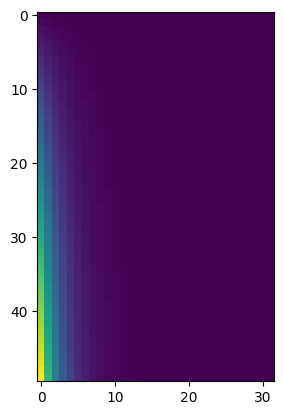

In [112]:
plt.imshow(freqs)

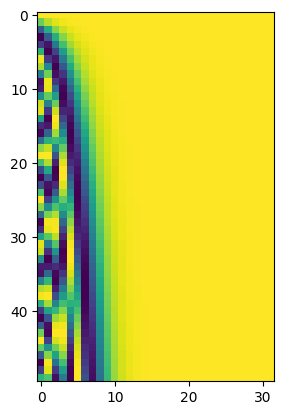

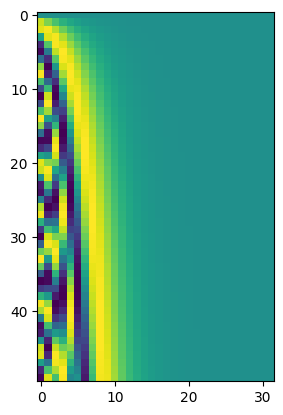

In [113]:
plt.imshow(freqs_cos)
plt.figure()
plt.imshow(freqs_sin)

Here is the query that we are processing. It has been "splitted" across multiple (32) attention heads

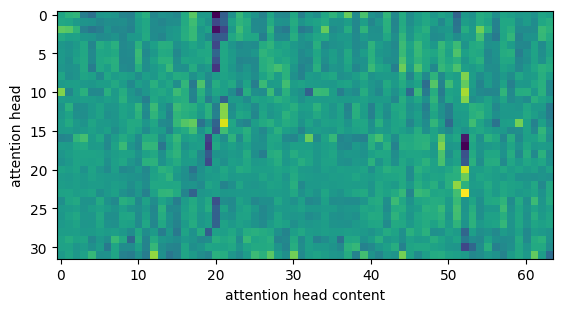

In [114]:
plt.ylabel("attention head")
plt.xlabel("attention head content")
plt.imshow(x_query)

The idea is that we will split the token embedding values in a sequence of pairs of numbers.
Each pair will be considered as a complex number. This produces `head_dim / 2` pairs per head (32 here),
each pair being considered as a complex number.

Each complex number is rotated using `freqs_cos` and `freqs_sin`. As of how these matrices are build this leads to an important "rotation" of the complex numbers at the beginning of the embedding vector and a very small rotation at the end. It encodes relative position through frequency-dependent phase shifts

In [120]:
display(f"RoPE input: {x_query.shape}")

# NOTE: here the implementation of Llama differs from what can be found in other transformer
# implementations (ex Karpathy's). The difference is how the embedded is splitted in real and
# imaginary parts. Karpathy's implementation uses successive values as real and imaginary parts,
# Llama uses the first half of the embedding as reals parts, and the second half as imaginary parts.
# We have to conform to the way the model has been trained.
x_query_real, x_query_img = np.split(x_query, 2, axis=-1)
display(f"Splitted as two tensors: {x_query_real.shape}, {x_query_img.shape}")
display(f"Complex number parts (index, num_attention_heads, head_dim / 2): {x_query_real.shape}, {x_query_img.shape}")

# Pluck out the row of freqs_cos and freqs_sin for the current token index
pos_freqs_cos = freqs_cos[token_index]
display(f"pos_freqs_cos: {pos_freqs_cos.shape}")
pos_freqs_sin = freqs_sin[token_index]
display(f"pos_freqs_sin: {pos_freqs_sin.shape}")

# Prepare result arrays for rotated real and imaginary parts
x_query_real_out = np.zeros_like(x_query_real)
x_query_img_out = np.zeros_like(x_query_img)
for head_index in range(num_attention_heads):
    # This loop isn't required as numpy could handle it through broadcasting.
    # It is only here for debugging / easier understanding

    cur_x_query_real = x_query_real[head_index]
    cur_x_query_img = x_query_img[head_index]

    # Actual complex numbers rotation.
    x_query_real_out[head_index] = cur_x_query_real * pos_freqs_cos - cur_x_query_img * pos_freqs_sin
    x_query_img_out[head_index] = cur_x_query_real * pos_freqs_sin + cur_x_query_img * pos_freqs_cos

# stack both real and imaginary parts back into a single tensor
x_query_rope = np.stack([x_query_real_out, x_query_img_out], axis=-1)
display(f"merged complex tensors: {x_query_rope.shape}")

# flatten complex numbers channels back into original shape
x_query_rope = x_query_rope.reshape(x_query_rope.shape[:-2] + (-1,))
display(f"RoPE result: {x_query_rope.shape}")


'RoPE input: (32, 64)'

'Splitted as two tensors: (32, 32), (32, 32)'

'Complex number parts (index, num_attention_heads, head_dim / 2): (32, 32), (32, 32)'

'pos_freqs_cos: (32,)'

'pos_freqs_sin: (32,)'

'merged complex tensors: (32, 32, 2)'

'RoPE result: (32, 64)'

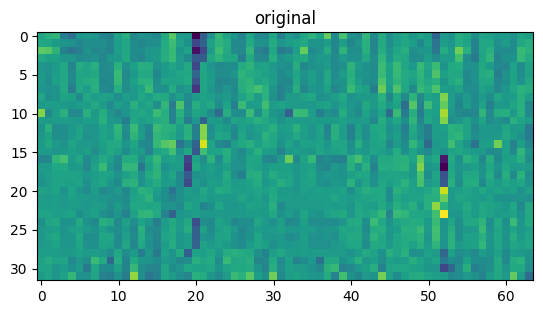

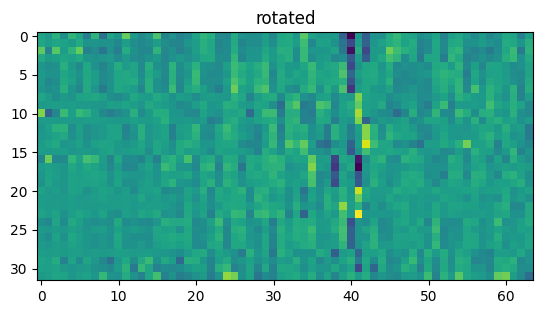

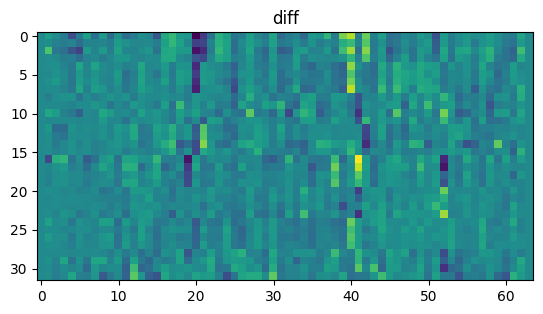

In [121]:
plt.title("original")
plt.imshow(x_query)
plt.figure()
plt.title("rotated")
plt.imshow(x_query_rope)
plt.figure()
plt.title("diff")
plt.imshow((x_query - x_query_rope))

In [124]:
# same for the key
x_key_real, x_key_img = np.split(x_key, 2, axis=-1)
pos_freqs_cos = freqs_cos[token_index]
pos_freqs_sin = freqs_sin[token_index]
x_key_real_out = np.zeros_like(x_key_real)
x_key_img_out = np.zeros_like(x_key_img)
for head_index in range(num_key_value_heads):
    cur_x_key_real = x_key_real[head_index]
    cur_x_key_img = x_key_img[head_index]
    x_key_real_out[head_index] = cur_x_key_real * pos_freqs_cos - cur_x_key_img * pos_freqs_sin
    x_key_img_out[head_index] = cur_x_key_real * pos_freqs_sin + cur_x_key_img * pos_freqs_cos
x_key_rope = np.stack([x_key_real_out, x_key_img_out], axis=-1)
x_key_rope = x_key_rope.reshape(x_key_rope.shape[:-2] + (-1,))

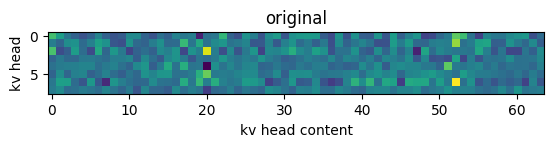

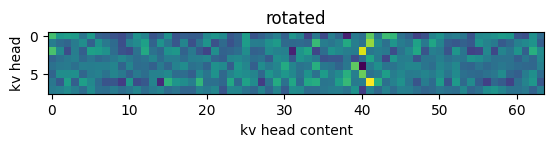

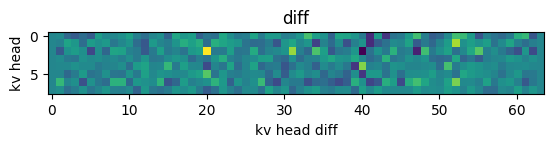

In [125]:
plt.title("original")
plt.ylabel("kv head")
plt.xlabel("kv head content")
plt.imshow(x_key)
plt.figure()
plt.title("rotated")
plt.ylabel("kv head")
plt.xlabel("kv head content")
plt.imshow(x_key_rope)
plt.figure()
plt.title("diff")
plt.ylabel("kv head")
plt.xlabel("kv head diff")
plt.imshow((x_key - x_key_rope))

Add the key and value to the corresponding caches. These caches contain the previously computed values for previous tokens. It's the memory of the transformer regarding the current context.

In [128]:
# Creating the KV (keys and values) cache. This will contain all keys and values computed since the
# first token. Here we are only processing a single token in a single transformer layer so this is
# isn't particularly usefull. We use it here for completeness
all_keys_cache = np.zeros((max_seq_len, num_key_value_heads, head_dim))
all_values_cache = np.zeros((max_seq_len, num_key_value_heads, head_dim))

# should not be -1, it is a hack to make this example work
all_keys_cache[token_index] = x_key_rope
all_values_cache[token_index] = x_value

Extract the keys and values from the cache from the first processed token up to the current one

In [129]:
all_keys = all_keys_cache[0: token_index + 1]
all_values = all_values_cache[0: token_index + 1]
display(all_keys.shape)
display(all_values.shape)

(1, 8, 64)

(1, 8, 64)

Grouped Query Attention

Each entry of the key and value matrices are repeated to match the dimension of the query.

Queries can stay fine-grained, while keys and values are shared across groups of heads to save memory and compute. Each group of query heads reuses the same key/value information.

In [133]:
repetitions = num_attention_heads // num_key_value_heads
display(f"repetitions = {repetitions}")

all_keys_grouped_query_attention = np.repeat(all_keys, repetitions, axis=1)
all_values_grouped_query_attention = np.repeat(all_values, repetitions, axis=1)

# flip the last dimensions to allow matrix multiplication
all_keys_grouped_query_attention = all_keys_grouped_query_attention.transpose(0, 2, 1)

display(f"xk_gqa: {all_keys_grouped_query_attention.shape}")
display(f"xv_gqa: {all_values_grouped_query_attention.shape}")

'repetitions = 4'

'xk_gqa: (1, 64, 32)'

'xv_gqa: (1, 32, 64)'

(32, 64)

(1, 64, 32)

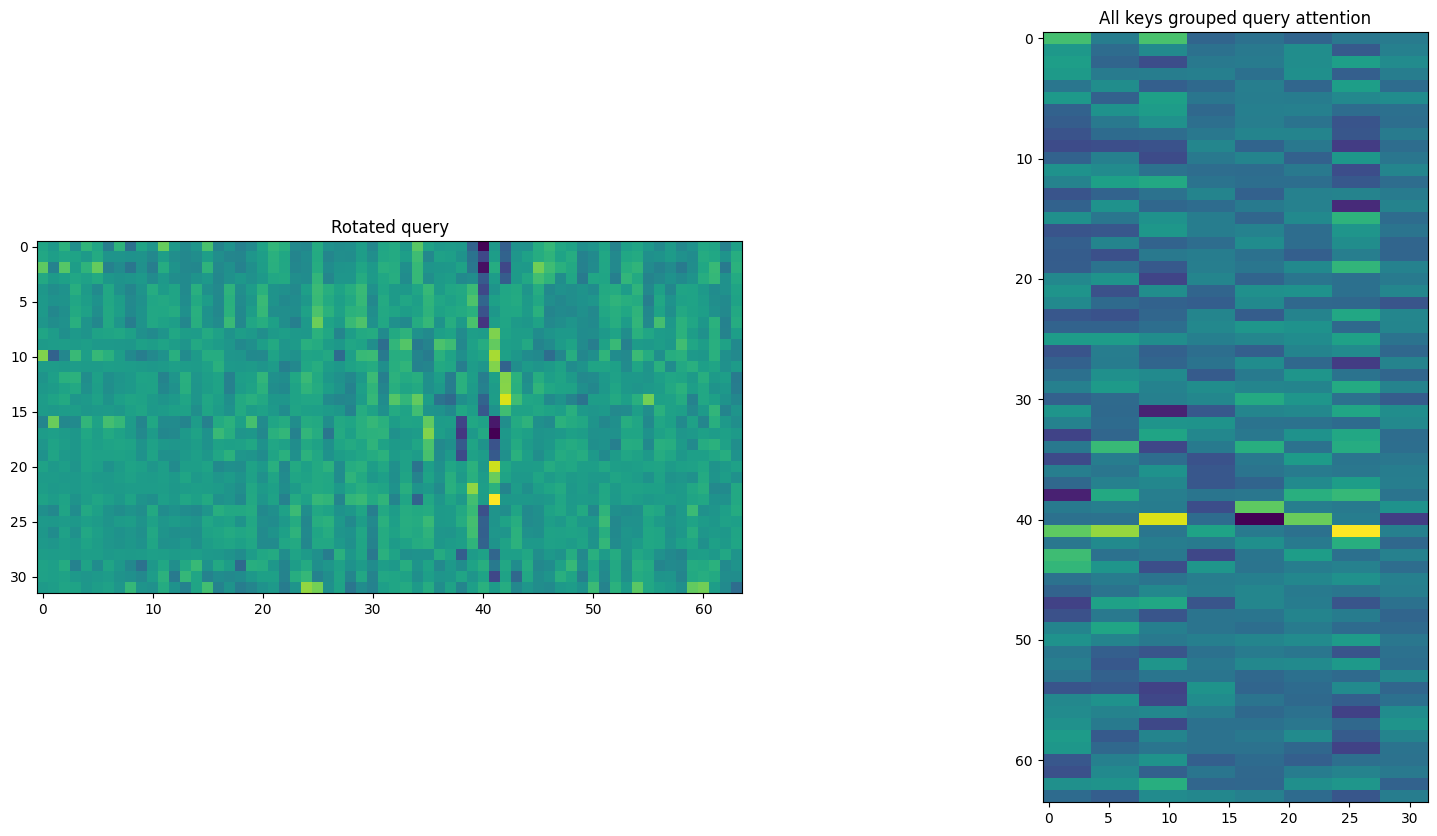

In [134]:
display(x_query_rope.shape)
display(all_keys_grouped_query_attention.shape)
fig, axes = plt.subplots(1, 2, figsize = (20,10))
axes[0].set_title("Rotated query")
axes[0].imshow(x_query_rope)
axes[1].set_title("All keys grouped query attention")
axes[1].imshow(all_keys_grouped_query_attention[0])

Matrix multiplication is the implementation of the dot-product for each entry of both matrices

This is a measure of "similarity" of both entries.

This can be interpreted as: We are looking in all keys available for the current token embedding which ones are matching the query. Or: of all concepts available for the current token embedding, which ones are the most relevent given the current query

In [135]:
attention = x_query_rope @ all_keys_grouped_query_attention
attention = attention / math.sqrt(head_dim)
display(attention.shape)

(1, 32, 32)

In [136]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

Skipping causal mask handling as we process a single token

In [137]:
attention = softmax(attention)
display(attention.shape)

(1, 32, 32)

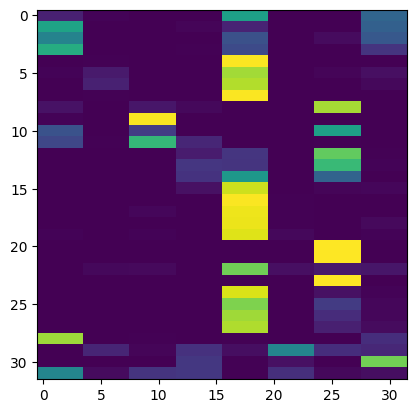

In [138]:
plt.imshow(attention[0])

Now that we have the attention scores, see which available token embedding values are the most relevant given these attention matrix

(1, 32, 64)

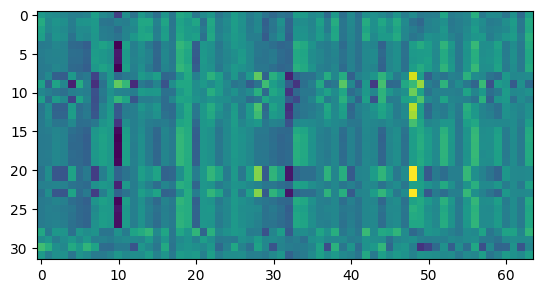

In [141]:
# Handle the value part of the attention
attention_scores = attention @ all_values_grouped_query_attention
plt.imshow(attention_scores[0])
display(attention_scores.shape)

Project the result in the output weights

In [142]:
attention_output = attention_scores.transpose(1, 0, 2).reshape(-1)
attention_output = attention_output @ output_weight
display(attention_output.shape)


(2048,)

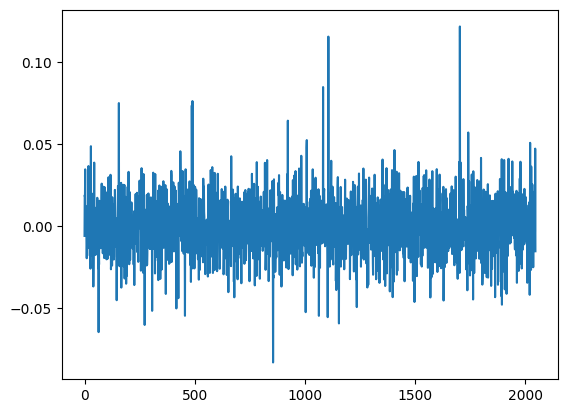

In [143]:
plt.plot(attention_output)

Post attention RMS normalization

In [144]:
post_attention_layernorm = RMSNorm(
    tensors[f"model.layers.{layer_index}.post_attention_layernorm.weight"],
    config["rms_norm_eps"]
)

In [145]:
post_attention_output = post_attention_layernorm(attention_output[0])

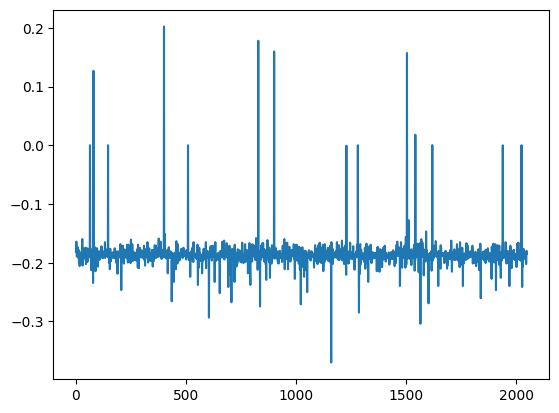

In [146]:
plt.plot(post_attention_output)

Transformer's feed forward layer

In [147]:
def silu(x):
    """
    Sigmoid Linear Unit
    The SiLU function is also known as the swish function.
    """
    return x * (1 / (1 + np.exp(-x)))

In [148]:
up_projection_weights = tensors[f"model.layers.{layer_index}.mlp.up_proj.weight"]
display(up_projection_weights.shape)
gate_projection_weights = tensors[f"model.layers.{layer_index}.mlp.gate_proj.weight"]
display(gate_projection_weights.shape)
down_projection_weights = tensors[f"model.layers.{layer_index}.mlp.down_proj.weight"]
display(down_projection_weights.shape)

(8192, 2048)

(8192, 2048)

(2048, 8192)

In [149]:
gate = silu((post_attention_output @ gate_projection_weights.T))
display(gate.shape)
up = post_attention_output @ up_projection_weights.T
fused = gate * up
feed_forward_output = fused @ down_projection_weights.T

(8192,)

In [150]:
transformer_output = attention_output + feed_forward_output
transformer_output.shape

(2048,)

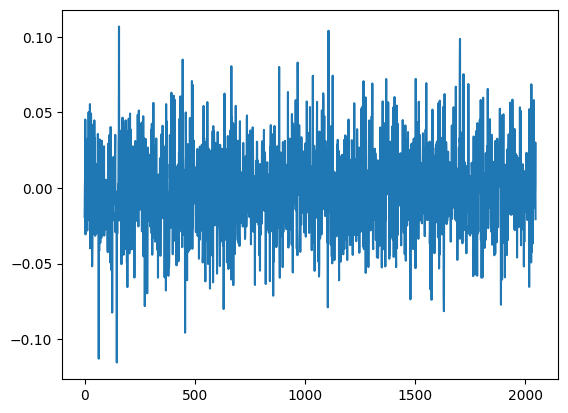

In [151]:
plt.plot(transformer_output)